### **CONTENTS**:

0) **Imports**: main packages imports
1) **Exploratory data analysis**: extract some basic stats with visualizations from our data and try to define if findings may inform constraints for evaluation and modelling;
2) **Basic data quality checks**: identification of invalid and duplicated docs in the data;
3) **Length-based analysis**: analysis and visualization of distribution differences based on text length criterion;
4) **Data splitting**: description of decision on data splitting;
5) **Metrics and evaluation logic**: defining what metrics are appropriate for models and how to evaluate them in a more appropriate way;
6) **Modelling with TF-IDF+LogReg with scores**: apply a couple of different modelling approaches from simples to heavier with a eval scores leaderboard comparison over defined metrics;
7) **Tuning OOD policy using baseline model to handle "other" class (OOD data)**
8) **Zero-shot Transformer experiment (optional confirmation of "other") deferred from TF-IDF**


#### **0. Imports**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import statistics
from itertools import combinations
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from dataclasses import dataclass,asdict 
from collections import Counter
from sklearn.model_selection import train_test_split
from zlib import crc32
from typing import Any, Mapping
from collections.abc import Iterable

In [2]:
# global vars:

DATASET_PATH = "data/dataset"
DATASET_ROOT = Path(DATASET_PATH)


#### **1. Exploratory Data Analysis**

##### Number of samples per class: investigating class imbalance

Let's first visualize out if we have any class imbalances to know if we need to handle this during modelling. I will define a small helper to count docs per class.

In [3]:
def count_files_per_class(dataset_root: str) -> dict:
    """
    Walk through the dataset root directory and count .txt files
    in each immediate subdirectory (class folder).
    """
    root = Path(dataset_root)
    class_counts = {}
    for subdir in sorted(root.iterdir()):
        if subdir.is_dir():
            # Count .txt files;
            txt_files = list(subdir.glob("*.txt"))
            class_counts[subdir.name] = len(txt_files)
    df = pd.DataFrame(list(class_counts.items()), columns=["class", "count"])
    return df

def barplot_wrapper(df, x="class",y="count",title="Document count per class"):
    """
    Create a boxplot of the document counts across classes,
    and a bar chart showing the count for each class.
    """
    # Bar chart: exact count for each class
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x=x, y=y, palette="viridis",hue=x,legend=False)
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Let's apply and visualize count_files_per_class results:

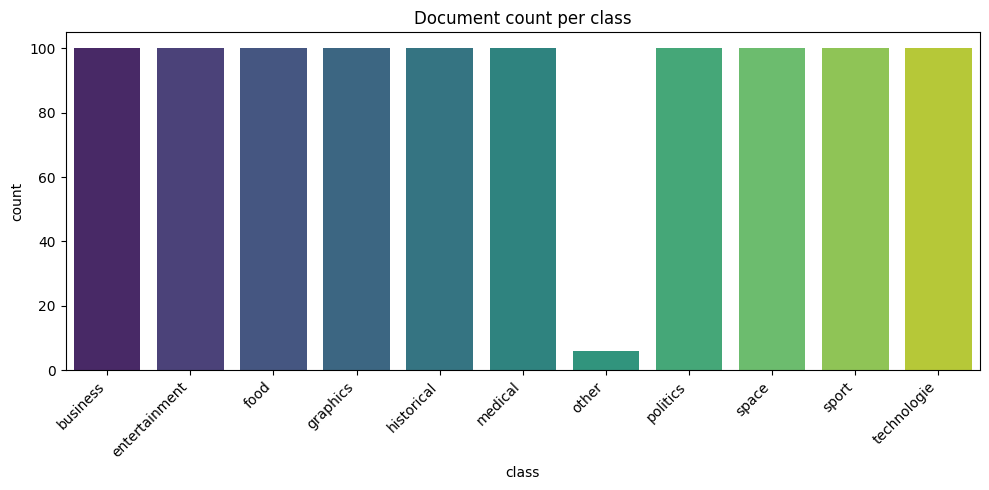

In [4]:
barplot_wrapper(count_files_per_class(DATASET_PATH))

**Conclusions**: 

- From a very high-level view, we do not have any class imbalance among "known" classes. We do not need to apply any specific sampling techniques or loss function modifications to cover-up specifically known class imbalance during training.
- However, we have a challenge with class "other"/out-of-distribution kind of documents. Technically we don't need to oversample it for training per se, but we still have to recognize this kind of documents during inference stage. This requires from us a robust rejection policy, i.e. some kind of threshold which rejects the class with maximum "softmax probability" output. We cannot have enough samples of "other" to make robust estimation of such a rejection policy with this number of "other" samples, so we need to create another way. Possible ideas may be: 1) Some OOD detection techniques like "leave-on-class-out"; 2) Synthetic data generation for "other" etc.

##### Median number of normalized tokens per document per class

Let's now analyze how classes differ substantially in number of median normalized tokens per example (a.k.a. "document length"). This finding may direct us to various modelling decisions about paramters of preprocessing (TF-IDF) or modelling (transformers), such as type of n-grams or max_token_count used. In my opinion, it is better to use median instead of average to avoid sensitivity for some too long/too short outlier examples.

In [5]:
def compute_median_norm_tokens_per_class(class_texts: dict, mode: str) -> pd.DataFrame:
    """
    In mode=="per_class": compute the median number of normalized tokens per example for each class
    In mode=="per_instance": compute the number of normalized tokens per example 
    Normalized tokens are lowercased word-like tokens (alphanumeric sequences).
    """
    
    if mode == 'per_class':
        rows = []
        for cls, texts in class_texts.items():
            # filter out non-string entries just in case
            texts = [t for t in texts if isinstance(t, str)]
            token_counts = []
            for text in texts:
                norm_tokens = re.findall(r"\b\w+\b", text.lower())
                token_counts.append(len(norm_tokens))
            median_val = statistics.median(token_counts) if token_counts else 0.0
            rows.append({"class": cls, "median_norm_tokens_num_per_example": median_val})
        df = pd.DataFrame(rows).sort_values("class").reset_index(drop=True)
    elif mode == 'per_instance':
        rows = []
        for cls, texts in class_texts.items():
            texts = [t for t in texts if isinstance(t, str)]
            token_counts = []
            for text in texts:
                norm_tokens = re.findall(r"\b\w+\b", text.lower())
                rows.append((cls, len(norm_tokens)))
        df = pd.DataFrame(rows, columns=["class", "token_count"])
        
    return df

In [6]:
class SourceText(str):
    """String text with source file metadata."""

    def __new__(cls, text: str, file_name: str):
        obj = str.__new__(cls, text)
        obj.file_name = file_name
        return obj


class_texts = {
    class_dir.name: [
        SourceText(
            text_file.read_text(encoding="utf-8", errors="ignore"),
            file_name=text_file.name,
        )
        for text_file in sorted(class_dir.glob("*.txt"))
    ]
    for class_dir in sorted(DATASET_ROOT.iterdir())
    if class_dir.is_dir()
}

In [7]:
med_norm_tokens_stats = compute_median_norm_tokens_per_class(class_texts, mode='per_class')

Now let's see distribution of of average number of normalized tokens per document in each class.

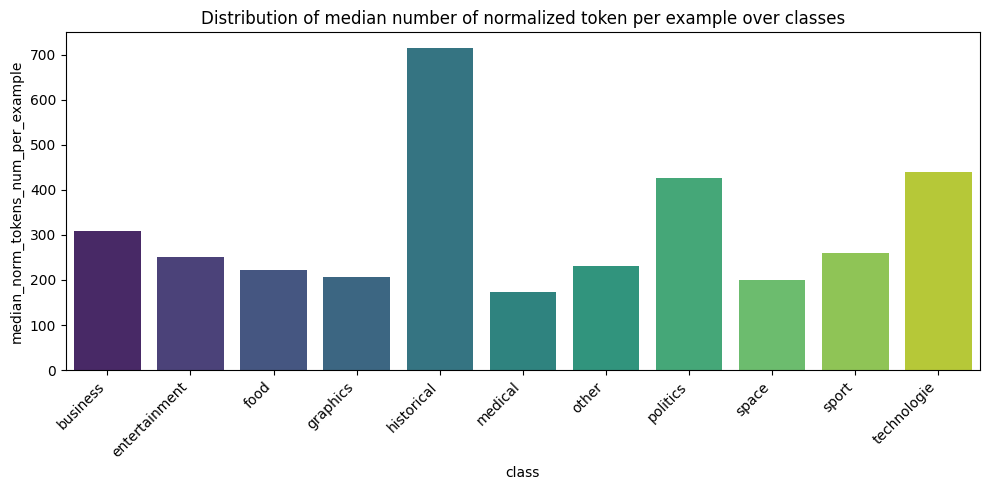

In [8]:
barplot_wrapper(med_norm_tokens_stats,x='class',y='median_norm_tokens_num_per_example',title='Distribution of median number of normalized token per example over classes')

The classes visibly differ in median document length.

**Conclusions:**

- Based on median document length, some fixed-context transformer models such as "all-MiniLM-L6-v2" with SetFit tuning may lose important information through truncation. This risk is most relevant for "historical", "technologie", "politics", and partly "business", because their typical documents are close to or above common transformer context limits such as 256 tokens. Thus, we should consider using pipelines/models which allow such parameter as "max_token_count" to be higher if we decide to use transformers ofc.
- Given that some classes are much "longer" than others, model performance may depend on document length, not only topic semantics. Hypothetically, a model may perform well on some shorter examples, but degrade on longer classes or vice versa. This may require class + length-bucket stratified splitting, and reporting metrics not only by class but also by length bucket.

##### Distribution visualization for number of normalized tokens per class

In [9]:
def boxplot_wrapper(df,x,y,title):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=x, y="token_count", palette="viridis",hue=x,legend=False)
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [10]:
norm_tokens_df = compute_median_norm_tokens_per_class(class_texts, mode='per_instance')

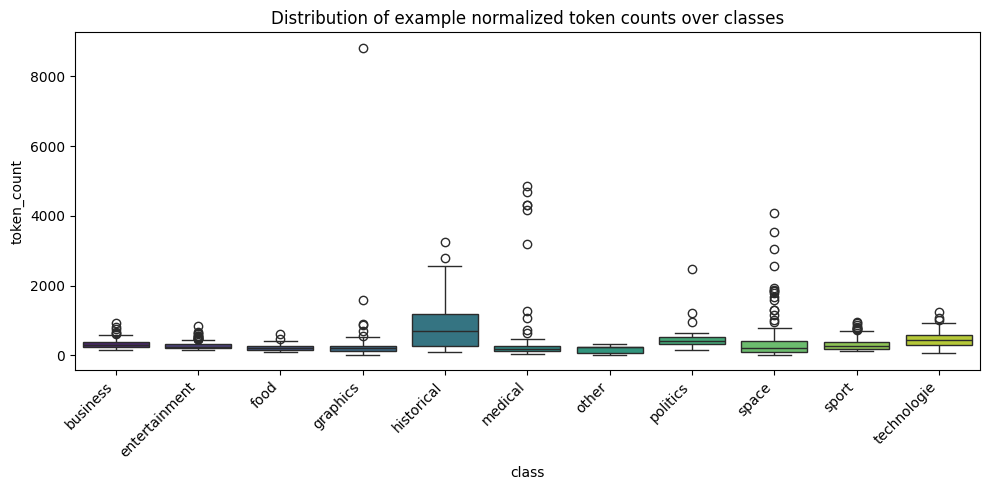

In [11]:
boxplot_wrapper(norm_tokens_df,'class','token_count','Distribution of example normalized token counts over classes')

We see a quite large number of outliers for medical and space.

**Conclusions**: 
- It seems to me that some documents won't be possible to be dealt with only tf-idf+classifier baseline, it may be not generalizable enough, so we need to pay more careful with preprocessing on truncation, vocabulary limits or rare-word filtering. Some router between lighter and heavier model may be needed that uses metadata on document length and unique=token count;
- Evaluation procedure should definitely include metrics reports over different length-buckets per each category;
- We also shall make sure that short documents are taken care of as well;
- We need to ensure data quality across all classes, i.e. at least the that some texts are not jibberish or duplicated multiple times one-sentence;

#### **2. Basic data quality checks**

##### 2.1 Invalid docs

We will first do some basic invalid docs checking, namely we will create InvalidDocumentAuditor class to check whether there are documents that are empty, too short or contain excessive non-printable characters.

In [12]:
"""Vectorized checks for invalid text-classification documents."""

class InvalidDocumentAuditor:
    """Load text documents and apply vectorized validity checks.
    
    The auditor flags documents that are empty, contain too few words to provide
    useful classification evidence, or contain excessive non-printable
    characters that may indicate corrupted text.
    
     Parameters
    ----------
    min_word_count : int, default=5
        Minimum number of English words required for a document to be considered
        valid.
    max_non_printable_ratio : float, default=0.05
        Maximum allowed proportion of non-printable characters.
    preview_length : int, default=160
        Maximum number of normalized characters included in review previews.

    Returns via def audit:
    -------
    results : pandas.DataFrame
        All documents with calculated measurements and validity flags.
    invalid_documents : pandas.DataFrame
        Only documents that fail at least one validity check.
    
    """

    FLAG_COLUMNS = ["is_empty", "is_too_short", "has_non_printable"]
    OUTPUT_COLUMNS = [
        "class",
        "file",
        "characters",
        "word_count",
        "non_printable_ratio",
        "reasons",
        "preview",
    ]

    def __init__(
        self,
        min_word_count: int = 5,
        max_non_printable_ratio: float = 0.05,
        preview_length: int = 160,
    ) -> None:
        """Store thresholds used to identify invalid documents."""

        if min_word_count < 0:
            raise ValueError("min_word_count must be non-negative")
        if not 0 <= max_non_printable_ratio <= 1:
            raise ValueError("max_non_printable_ratio must be between 0 and 1")
        if preview_length < 0:
            raise ValueError("preview_length must be non-negative")
        self.min_word_count = min_word_count
        self.max_non_printable_ratio = max_non_printable_ratio
        self.preview_length = preview_length

    def audit(self, dataset_root: str | Path) -> tuple[pd.DataFrame, pd.DataFrame]:
        """Return all flagged documents and the invalid subset."""

        documents = self.load_documents(dataset_root)
        measured = self._measure_documents(documents)
        return self.flag_invalid_documents(measured)

    def load_documents(self, dataset_root: str | Path) -> pd.DataFrame:
        """Read each class text file once into a document-level DataFrame."""

        paths = sorted(Path(dataset_root).glob("*/*.txt"))
        return pd.DataFrame(
            [
                {
                    "class": path.parent.name,
                    "file": path.name,
                    "text": path.read_text(encoding="utf-8", errors="replace"),
                }
                for path in paths
            ],
            columns=["class", "file", "text"],
        )

    def _measure_documents(self, documents: pd.DataFrame) -> pd.DataFrame:
        """Calculate document statistics with vectorized operations.

        Expects class, file, and text columns produced by ``load_documents``.
        Computes character, English-word, and non-printable-character measures
        without deciding whether a document is invalid. It also creates a short,
        whitespace-normalized preview and returns the results in a copied frame.
        """

        result = documents.copy()
        text = result["text"].astype("string")
        result["characters"] = text.str.len()
        result["word_count"] = text.str.count(r"\b[A-Za-z]+\b")
        non_printable_count = text.str.count(r"[^\x20-\x7E\r\n\t]")
        denominator = result["characters"].replace(0, pd.NA)
        result["non_printable_ratio"] = non_printable_count.div(denominator).fillna(0.0)
        result["preview"] = (
            text.str.replace(r"\s+", " ", regex=True)
            .str.strip()
            .str[: self.preview_length]
        )
        return result

    def flag_invalid_documents(
        self, measured: pd.DataFrame
    ) -> tuple[pd.DataFrame, pd.DataFrame]:
        """Apply validity rules, add reasons, and return invalid rows.

        Uses the configured thresholds to create one Boolean column per rule.
        A document is invalid when at least one rule evaluates to true. The first
        returned frame contains all documents and flags; the second contains only
        invalid rows with the columns needed for review.
        """

        result = measured.copy()
        result["is_empty"] = result["text"].astype("string").str.strip().eq("")
        result["is_too_short"] = result["word_count"].lt(self.min_word_count)
        result["has_non_printable"] = result["non_printable_ratio"].gt(
            self.max_non_printable_ratio
        )
        result["reasons"] = self._build_reasons(result)
        invalid_mask = result[self.FLAG_COLUMNS].any(axis=1)
        invalid = result.loc[invalid_mask, self.OUTPUT_COLUMNS].reset_index(drop=True)
        return result, invalid

    def _build_reasons(self, documents: pd.DataFrame) -> pd.Series:
        """Create readable reason labels from the configured rules.

        Expects the Boolean rule columns created by ``flag_invalid_documents``.
        Maps each true flag to a threshold-aware label and joins all applicable
        labels for each document. Valid documents receive an empty string, while
        documents failing multiple checks retain every failure reason.
        """

        ratio_percent = self.max_non_printable_ratio * 100
        reasons = (
            documents["is_empty"].map({True: "empty; ", False: ""})
            + documents["is_too_short"].map(
                {True: f"fewer_than_{self.min_word_count}_words; ", False: ""}
            )
            + documents["has_non_printable"].map(
                {True: f"more_than_{ratio_percent:g}_percent_non_printable; ", False: ""}
            )
        )
        return reasons.str.removesuffix("; ")

In [13]:
doc_auditor = InvalidDocumentAuditor()
results, invalid = doc_auditor.audit(DATASET_ROOT)
print(invalid)

Empty DataFrame
Columns: [class, file, characters, word_count, non_printable_ratio, reasons, preview]
Index: []


It seems like our InvalidDocumentAuditor was not able to find any evident gaps. I do not exclude possibility that we missed some check or that configuration is missing something. In m opinio there is always a necessity to do some manual visual human sanity check for few samples to make sure it's alright.

##### 2.2 Exact and near-duplicates duplicates check

We will create DuplicateDocumentAuditor which finds exact and near-duplicates. Exact duplicates are handled relatively easy, but for near duplicates we need to explain few things here. 

To detect these we use a concept of shingle (i.e. "word n-gram" / or sequence of consecutive tokens) for calculating two similarity metrics: jaccard and overlap coefficient. Jaccard just measures number of overlapping shingles for two or more docs divided by total number of unique shigles across all docs.  

However, one or more docs may be just an excerpt from the larger one, so we need also a overlapping coefficient, i.e. number of overlapped shingles divided by total number of unique shingles in smaller docs. In some edge cases jaccard score may be very low, while overlapping coefficient may be around 1. We would still use jaccard coefficient though to handle cases with noise in excerpt docs. 

Our default minimal values for jaccard and overlapping coefs in near-duplicates case will be 0.92 and 0.95 respectively. Number of tokens in shingles for comparison was decided to be 5. It is more or less balanced number to avoid accidental matches for generic phrases in case of say 2 shingles or too strict approach. We also decided that the doc shall contain at least 3 shingles to be considered for duplicate check. It prevents shared titles or sentences to be marked as duplicates.

We will also add previews for found duplicates for quick visual check, though I still think if the number of duplicates is not too high then manual review must be preferred.

We will do duplicates check inside each class and across classes as well.

In [14]:
class DuplicateDocumentAuditor:
    """Find exact and near duplicates, then produce notebook review tables."""

    TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
    GROUP_COLUMNS = [
        "member_count",
        "classes",
        "files",
        "previews",
        "cross_class",
        "overlap_coefficients",
    ]

    def __init__(
        self,
        shingle_size: int = 5,
        near_duplicate_jaccard: float = 0.92,
        overlap_threshold: float = 0.95,
        min_smaller_shingles: int = 20,
        preview_length: int = 160,
    ) -> None:
        """Store near-duplicate matching thresholds."""

        self.shingle_size = shingle_size
        self.near_duplicate_jaccard = near_duplicate_jaccard
        self.overlap_threshold = overlap_threshold
        self.min_smaller_shingles = min_smaller_shingles
        self.preview_length = preview_length

    def audit(
        self,
        dataset_root: str | Path,
    ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """Return documents, exact-duplicate groups, and near-duplicate groups."""

        documents = self._load_documents(dataset_root)
        text = documents["text"].astype("string")
        documents["normalized_text"] = text.map(self._normalize)
        documents["token_count"] = documents["normalized_text"].str.count(r"\S+")
        documents["preview"] = (
            text.str.replace(r"\s+", " ", regex=True)
            .str.strip()
            .str[: self.preview_length]
        )

        return (
            documents,
            self._exact_groups(documents),
            self._near_groups(documents),
        )

    def names_excluding_largest(
        self,
        documents: pd.DataFrame,
        duplicate_groups: pd.DataFrame,
    ) -> list[str]:
        """Return duplicate filenames while retaining the largest document per group."""

        token_counts = documents.set_index(["class", "file"])["token_count"].to_dict()
        excluded = []

        for group in duplicate_groups.itertuples(index=False):
            members = list(zip(group.classes, group.files))
            retained = min(
                members,
                key=lambda member: (-token_counts[member], member[0], member[1]),
            )
            excluded.extend(
                file_name
                for member_class, file_name in members
                if (member_class, file_name) != retained
            )

        return sorted(set(excluded))

    def _exact_groups(self, documents: pd.DataFrame) -> pd.DataFrame:
        """Summarize groups with identical normalized text."""

        rows = [
            self._group_row(group, [1.0] * (len(group) * (len(group) - 1) // 2))
            for _, group in documents.groupby("normalized_text", dropna=False)
            if len(group) > 1
        ]
        return pd.DataFrame(rows, columns=self.GROUP_COLUMNS)

    def _near_groups(self, documents: pd.DataFrame) -> pd.DataFrame:
        """Find connected components of non-exact near-duplicate pairs."""

        rows = list(documents.itertuples())
        shingles = [self._shingles(row.text) for row in rows]
        edges = []

        for left_index, right_index in combinations(range(len(rows)), 2):
            left, right = rows[left_index], rows[right_index]
            if left.normalized_text == right.normalized_text:
                continue

            shared = len(shingles[left_index] & shingles[right_index])
            smaller_count = min(len(shingles[left_index]), len(shingles[right_index]))
            jaccard = shared / len(shingles[left_index] | shingles[right_index])
            overlap = shared / smaller_count if smaller_count else 0.0

            if (
                jaccard >= self.near_duplicate_jaccard
                or (
                    overlap >= self.overlap_threshold
                    and smaller_count >= self.min_smaller_shingles
                )
            ):
                edges.append((left_index, right_index, overlap))

        parent = {}

        def find(index: int) -> int:
            parent.setdefault(index, index)
            if parent[index] != index:
                parent[index] = find(parent[index])
            return parent[index]

        # Union matching pairs so chains such as A-B-C become one review group.
        for left_index, right_index, _ in edges:
            left_root, right_root = find(left_index), find(right_index)
            if left_root != right_root:
                parent[right_root] = left_root

        components = {}
        for index in parent:
            components.setdefault(find(index), set()).add(index)

        summaries = []
        for indices in components.values():
            group = documents.iloc[sorted(indices)]
            overlaps = [
                overlap
                for left_index, right_index, overlap in edges
                if {left_index, right_index} <= indices
            ]
            summaries.append(self._group_row(group, overlaps))

        return pd.DataFrame(summaries, columns=self.GROUP_COLUMNS)

    def _shingles(self, text: str) -> set[str]:
        """Create overlapping token shingles for one document."""

        tokens = self.TOKEN_RE.findall(text.lower())
        if len(tokens) < self.shingle_size:
            return {" ".join(tokens)} if tokens else set()

        return {
            " ".join(tokens[index : index + self.shingle_size])
            for index in range(len(tokens) - self.shingle_size + 1)
        }

    def _group_row(
        self,
        group: pd.DataFrame,
        overlaps: list[float],
    ) -> dict[str, object]:
        """Build the compact group shape used by the notebook."""

        group = group.sort_values(["class", "file"])
        classes = group["class"].tolist()

        return {
            "member_count": len(group),
            "classes": classes,
            "files": group["file"].tolist(),
            "previews": group["preview"].tolist(),
            "cross_class": len(set(classes)) > 1,
            "overlap_coefficients": [round(value, 4) for value in overlaps],
        }

    @staticmethod
    def _load_documents(dataset_root: str | Path) -> pd.DataFrame:
        """Read every class text file into one DataFrame."""

        paths = sorted(Path(dataset_root).glob("*/*.txt"))
        return pd.DataFrame(
            [
                {
                    "class": path.parent.name,
                    "file": path.name,
                    "text": path.read_text(encoding="utf-8", errors="replace"),
                }
                for path in paths
            ]
        )

    @classmethod
    def _normalize(cls, text: str) -> str:
        """Normalize word-like tokens for exact comparison."""

        return " ".join(cls.TOKEN_RE.findall(text.lower()))

In [15]:
duplicate_auditor = DuplicateDocumentAuditor(near_duplicate_jaccard=0.80,
                                             min_smaller_shingles=3)
results, exact_duplicates, near_duplicates = duplicate_auditor.audit(DATASET_ROOT)

In [16]:
print('Number of exact duplicates:',exact_duplicates.shape[0])
print('Number of near-duplicates:',near_duplicates.shape[0])
print('Number of cross-class duplicates of any type:', 
      near_duplicates.cross_class.astype(int).sum() +
      exact_duplicates.cross_class.astype(int).sum())
print('')
print('Number of docs corresponding to duplicate text:')
print('For exact duplicates:',exact_duplicates.member_count.value_counts())
print('For near duplicates:',near_duplicates.member_count.value_counts())


Number of exact duplicates: 8
Number of near-duplicates: 22
Number of cross-class duplicates of any type: 0

Number of docs corresponding to duplicate text:
For exact duplicates: member_count
2    8
Name: count, dtype: int64
For near duplicates: member_count
2    20
3     2
Name: count, dtype: int64


We were able to find both 8 exact (each duplicate text corresponds to 2 docs) and 22 near duplicates (20 duplicate texts correspond to 2 docs and only 2 duplicate texts correspond to 3 docs).  

There are 0 cross-class duplicates though. 

Let's examine exact ones previews first as there are only 8 of these.

In [17]:
for idx in range(exact_duplicates.shape[0]):
    print(exact_duplicates.iloc[idx].files)
    for preview in exact_duplicates.iloc[idx].previews:
        print(preview)
    print('')

['politics_117.txt', 'politics_287.txt']
Boothroyd calls for Lords speaker Betty Boothroyd has said the House of Lords needs its own Speaker and that peers should lead the way on reforming the upper ch
Boothroyd calls for Lords speaker Betty Boothroyd has said the House of Lords needs its own Speaker and that peers should lead the way on reforming the upper ch

['sport_12.txt', 'sport_20.txt']
Edwards tips Idowu for Euro gold World outdoor triple jump record holder and BBC pundit Jonathan Edwards believes Phillips Idowu can take gold at the European I
Edwards tips Idowu for Euro gold World outdoor triple jump record holder and BBC pundit Jonathan Edwards believes Phillips Idowu can take gold at the European I

['entertainment_41.txt', 'entertainment_48.txt']
Famed music director Viotti dies Conductor Marcello Viotti, director of Venice's famous La Fenice Theatre, has died in Germany at 50. Viotti, director of La Fen
Famed music director Viotti dies Conductor Marcello Viotti, director o

Most of matches for exact ones look true from "preview" column. I also examined manually all these files and the rest of the text. All texts are exact duplicates indeed. We will save names of each arbitrary file member of exact duplicate list (as they are equally important) via "save_duplicate_names" to remove them later.

In [18]:
EXACT_DUPLICATE_NAMES = duplicate_auditor.names_excluding_largest(
            results, exact_duplicates
        )

Given that we were able to identify 22 near-duplicates, it would already be somewhat time-consuming to manually check everything. Let's first see what is min overlap_coefficient that can be in a range [0,1] over all 22 near-duplicates:

In [19]:
overlap_vals = [coef for lst_coefs in near_duplicates.overlap_coefficients.to_list() for coef in lst_coefs]
print('Min overlap.coef:',min(overlap_vals))

Min overlap.coef: 0.9133


As we can see, all detected near-duplicate groups have overlap above 90%. This means that, in each group, most of the smaller document is contained in the larger one, so it is reasonable to treat the smaller documents as excerpts rather than independent examples.

In a larger production dataset with thousands of near duplicates, I would use stricter automatic-deletion rules and additional safeguards, such as a higher minimum number of shared shingles or a manual-review sample. However, for this home assignment the number of duplicate groups is small, and we already require a minimum amount of shared text before flagging a pair. Given that, it is reasonable to keep only the largest document from each duplicate group and exclude the shorter excerpt-like versions from the modelling dataset.

In [20]:
NEAR_DUPLICATE_NAMES = duplicate_auditor.names_excluding_largest(
            results, near_duplicates
        )

We are planning to leave only 1 file in training data from each pair or triplet of exact and near (larger one) duplicate. We expect there would be a miniscule or almost no change in unique tokens distribution as we are removing mostly repeated docs, but we will check if this is true separately. Let's also make sure we don't have some class left underrepresented during training after deletion of duplicates. If it is the case we may want to use some kind of synthetic data generation or real data chunking. 

First, let's visually check classes occurence distribution:

In [21]:
near_dupl_classes_names = []
for idx,row in near_duplicates.iterrows():
      near_dupl_classes_names.extend((row['member_count']-1)*[row['classes'][0]])

exact_classes_names = [lst[0] for lst in exact_duplicates.classes.tolist()]

print('Distribution of exact classes:',
      dict(Counter(exact_classes_names)))
print('')
print('Distribution of near-duplicate classes:',
      dict(Counter(near_dupl_classes_names)))

Distribution of exact classes: {'politics': 2, 'sport': 2, 'entertainment': 2, 'technologie': 1, 'business': 1}

Distribution of near-duplicate classes: {'entertainment': 2, 'food': 1, 'graphics': 4, 'historical': 5, 'medical': 5, 'politics': 2, 'space': 2, 'sport': 1, 'technologie': 2}


It seems like for exact classes are uniformly distributed among classes. Near-duplicates are more biased towards medical, historical and graphics, though the difference from others do not seem critical. In general duplicate removal does not meaningfully distort class balance. The largest class-level reduction is around 5 documents out of 100, and the affected classes still retain enough examples for somtething like TF-IDF + logistic regression training or small LM finetuning. Let's check how how vocabulary changes.

First, let's create unique_normalized_tokens_per_class which will count for us vocabulary change before and after all duplicates removal:

In [22]:
def unique_normalized_tokens_per_class(dataset_root, excluded_files=None):
    """Count unique normalized tokens per class, optionally excluding files."""

    excluded_files = set(excluded_files or [])
    rows = []

    for class_dir in sorted(Path(dataset_root).iterdir()):
        if not class_dir.is_dir():
            continue

        tokens = set()

        for path in sorted(class_dir.glob("*.txt")):
            if path.name in excluded_files:
                continue

            text = path.read_text(encoding="utf-8", errors="replace")
            tokens.update(re.findall(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?", text.lower()))

        rows.append({
            "class": class_dir.name,
            "unique_normalized_tokens": len(tokens),
        })

    return pd.DataFrame(rows)

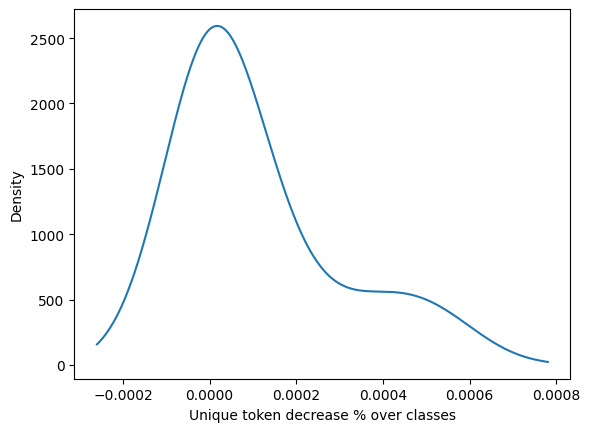

In [23]:
before_vocab = unique_normalized_tokens_per_class(DATASET_ROOT)

excluded_files = (
    EXACT_DUPLICATE_NAMES
    + NEAR_DUPLICATE_NAMES
)

after_vocab = unique_normalized_tokens_per_class(
    DATASET_ROOT,
    excluded_files=excluded_files,
)

vocab_change = before_vocab.merge(
    after_vocab,
    on="class",
    suffixes=("_before", "_after"),
)

((
    vocab_change["unique_normalized_tokens_before"]
    - vocab_change["unique_normalized_tokens_after"]
) / (vocab_change["unique_normalized_tokens_before"])).plot(kind='kde')
plt.xlabel('Unique token decrease % over classes')
plt.show()

As expected, removing repeated documents almost do not change unique token count over classes. 

**Conclusions**:
- What was found: 8 pairs of exact duplicates, 20 pairs and 2 triplets of near duplicates in our dataset. 
- Each near-duplicate is in fact an excerpt from larger document in pair/triple.
- Duplicate removal does not meaningfully distort class balance or unique normalized token coverage and only decreases redundancy.

#### **3. Length-based analysis**

Let's check how texts frequencies depend on text length. If there is some difference, we will have to change our evaluation, data splitting, modelling and maybe even prediction logic in order to make sure that our API inference is able to handle texts of various length. 

Depending on the number of token we will divide our length buckets into "ultra-short", "short", "medium", "long" and "extra-long". This induces us to use tail-aware empirical bucketing rule, i.e. quantiles at [0, 0.10, 0.75, 0.90]. We will use these to isolate isolate very short inputs,
the main corpus body, long documents, and extreme long-tail documents. We will exclude previously found exact and near duplicates from our analysis.

Let's first read our texts:

In [24]:
def texts_for_quantiles(
    class_texts: dict[str, list[str]],
    excluded_labels: set[str] = {"other"},
    excluded_files: list[str] | set[str] = (),
) -> list[dict[str, str]]:
    """Return filtered labeled texts without changing class_texts."""
    excluded_files = set(excluded_files)
    rows = []

    for label, texts in class_texts.items():
        if label in excluded_labels:
            continue

        for text in texts:
            if text.file_name in excluded_files:
                continue

            rows.append({
                "class": label,
                "file_name": text.file_name,
                "text": str(text),
            })

    return rows

In [25]:
dataset_texts = texts_for_quantiles(
    class_texts,
    excluded_labels={"other"},
    excluded_files=excluded_files,
)

Let's find our length buckets:

In [26]:
TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
counts = pd.Series(row["text"] for row in dataset_texts).str.count(TOKEN_RE)

LABELLED_QUANTILES = {"ultra_short":0, 
                        "short":0.10, 
                        "medium":0.75, 
                        "long": 0.90}

VALUES_AT_Q = counts.quantile(
    list(LABELLED_QUANTILES.values()),
    interpolation="nearest",
).astype(int)

for bucket_label, quantile in LABELLED_QUANTILES.items():
    print(f"{bucket_label}: <= {VALUES_AT_Q[quantile]}")
print(f"extra_long: > {VALUES_AT_Q[0.9]}")

ultra_short: <= 19
short: <= 126
medium: <= 445
long: <= 779
extra_long: > 779


These quantile-derived thresholds define ultra_short as up to 19 tokens, short up to 126, medium up to 445, long up to 779, and anything above 779 as extra_long.

Let's create a function that may be used to return length-bucket label based on input text:

In [27]:
def length_bucket(text: str) -> str:
    """Assign a quantile-derived word-count bucket."""
    word_count = len(TOKEN_RE.findall(text))
    for bucket_name, quantile in LABELLED_QUANTILES.items():
        if word_count <= int(VALUES_AT_Q.loc[quantile]):
            return bucket_name
    return "extra_long"

Now let's calculate and plot number of unique normalized token count per each length bucket to see the differences across classes.

In [28]:
def compute_vocabulary_stats_by_bucket(dataset_texts: list[dict[str, str]]) -> pd.DataFrame:
    """For each class and length bucket compute number of examples."""
    rows = []

    for row in dataset_texts:
        bucket = length_bucket(row["text"])
        rows.append((row["class"], bucket))

    df = pd.DataFrame(rows, columns=["class", "bucket"])
    df = df.value_counts(["class", "bucket"]).reset_index(name="num_examples")

    bucket_order = ["ultra_short", "short", "medium", "long", "extra_long"]
    df["bucket"] = pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)

    return df.sort_values(["class", "bucket"]).reset_index(drop=True)

In [29]:
vocab_stats_per_bucket = compute_vocabulary_stats_by_bucket(dataset_texts)

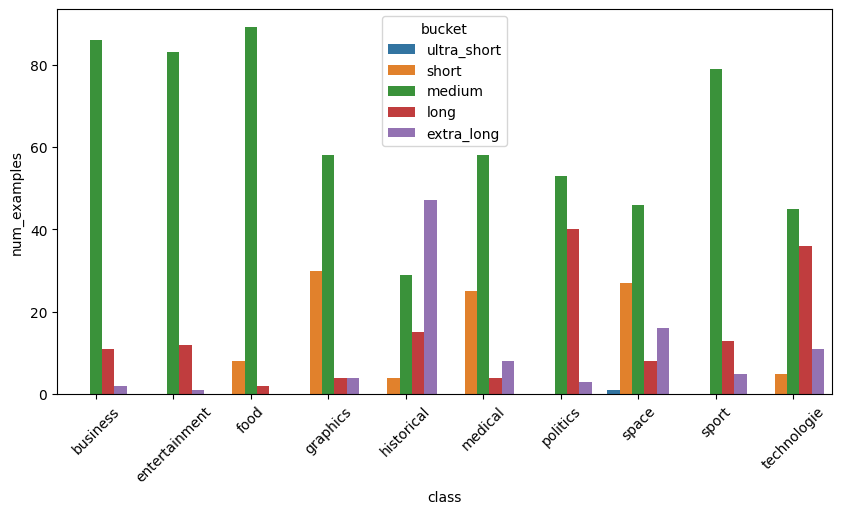

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(vocab_stats_per_bucket,x="class", y="num_examples", hue="bucket")
plt.xticks(rotation=45)
plt.show()

**Conclusions**:
- Text length is not evenly spread across classes: most classes are mainly "medium", but "historical" is dominated by "extra_long" examples, also "politics" and "technologie" have more "long" one than other classes contain.
- For evaluation, aggregate or per-class metrics are not enough. We should also check performance by length bucket, especially for "long" and "extra_long" texts. However, splitting into (class, length-bucket type) specifically for training may be too granular. We will report metrics grouped by two fields separately, but splitting will be done on our main target (i.e. classes) basis.

#### **4. Data Splitting**

Let's remind ourselves how classes distribution looks like after duplicates deletions:

In [31]:
class_labels = [item['class'] for item in dataset_texts]
Counter(class_labels)

Counter({'business': 99,
         'food': 99,
         'space': 98,
         'sport': 97,
         'technologie': 97,
         'entertainment': 96,
         'graphics': 96,
         'politics': 96,
         'historical': 95,
         'medical': 95})

The class frequencies are already quite balanced: each known class has roughly 95-99 examples after duplicate filtering. If we only looked at class counts, a simple stratified split by class would look sufficient. We also cannot use also length buckets for splitting in (class,length_bucket) format because crossing class with length will create many sparse groups with zero samples in test sets and especially in validation folds during Stratified KFold cross-validation. However, we will still create a length-bucket label: not for data splitting, but for reporting evaluation.

Let's now create a dataframe which contains all data and class and length-bucket labels before splitting.

In [32]:
def stratification_key(row: dict) -> str:
    """Return the joint class and length-bucket stratum."""
    return f"{row['class']}__{row['bucket']}"


dataset_for_split = pd.DataFrame(dataset_texts)
dataset_for_split["bucket"] = dataset_for_split["text"].map(length_bucket)

In [33]:
dataset_for_split.head(3)

,class,file_name,text,bucket
0,business,business_1.txt,Lufthansa flies back to profit\n\nGerman airli...,medium
1,business,business_10.txt,Winn-Dixie files for bankruptcy\n\nUS supermar...,medium
2,business,business_100.txt,US economy still growing says Fed\n\nMost area...,medium


Let's do a reproducible stratified splitting with test data to be 15%:

In [34]:
def split_one_group(
    group: pd.DataFrame,
    test_frac: float = 0.15,
    random_state: int = 42,
) -> pd.Series:
    """Assign train/test labels inside one class with a class-specific seed."""
    # group.name is the class key from groupby("class").
    class_seed = (random_state + crc32(str(group.name).encode())) % 2**32
    group = group.sample(frac=1, random_state=class_seed)

    n_test = max(1, round(len(group) * test_frac))
    n_test = min(n_test, len(group) - 1)

    splits = ["train"] * (len(group) - n_test) + ["test"] * n_test
    return pd.Series(splits, index=group.index)

In [35]:
dataset_for_split["split"] = (
    dataset_for_split
    .groupby("class", group_keys=False)
    .apply(split_one_group)
)

train_df = dataset_for_split.query("split == 'train'").copy()
test_df = dataset_for_split.query("split == 'test'").copy()

We do not need validation subset as we will be doing stratified KFold cross-validation hyperparameter tuning to find the best set of params.

#### **5. Metrics and evaluation logic**

This is a multiclass classification task, so the main metric is accuracy: the share of documents where the predicted class is exactly equal to the true class. Accuracy alone is not enough, though. A model can have decent overall accuracy while still performing badly on one or two classes. For that reason, we also report balanced accuracy. In this setting, balanced accuracy is the average of per-class accuracies, so each class has the same weight regardless of its number of examples.

We also report macro F1 as a stricter class-balanced metric. It combines precision and recall per class, then averages across classes. This helps catch models that overpredict some classes and underpredict others.

For grouped analysis, we keep the interpretation simple: we report sample count and accuracy by class, and sample count and accuracy by length bucket.

Despite data splitting only by class, short texts may not contain enough signal, while long texts may contain mixed or noisy information. Because of that, we evaluate model quality along two separate axes: class and length-bucket. We will have "score_by_group" function responsible for that.

In [36]:
class ClassificationScorer:
    """Compute overall and grouped classification metrics."""

    def __init__(self, labels: list[str]):
        self.labels = labels

    def score_predictions(self, y_true, y_pred) -> dict:
        """Compute main multiclass metrics."""
        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                labels=self.labels,
                average="macro",
                zero_division=0,
            ),
        }

    def score_by_group(self, df: pd.DataFrame, group_col: str) -> pd.DataFrame:
        """Compute sample count and accuracy for each group."""
        rows = []

        for group_name, group_df in df.groupby(group_col):
            rows.append({
                group_col: group_name,
                "sample_count": len(group_df),
                "accuracy": accuracy_score(
                    group_df["class"],
                    group_df["predicted_label"],
                ),
            })

        return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)

#### **6. Modelling with TF-IDF+LogReg with scores**

##### TF-IDF + LogReg hyperparameters grid search

For the notebook experiment, we use the same basic model family as the production training code: TF-IDF features followed by logistic regression. Here we keep only parts needed for a clear baseline experiment.

We train 3 small TF-IDF/logistic-regression candidates on the training split and choose the best one averaging over folds in Stratified KFold manner. The selection metric is balanced accuracy, because it gives equal weight to each class. After selecting the best candidate, we refit it on all training data, evaluating it afterwards on the test split and out-of-distribution "other" class.

*ModelFactory* builds reproducible TF-IDF and Logistic Regression pipelines from a candidate configuration, keeping model construction separate from tuning and evaluation.

In [37]:
class ModelFactory:
    """Build TF-IDF + logistic-regression models."""

    def __init__(self, random_state: int = 42):
        self.random_state = random_state

    def build_tfidf_logreg(self, config: dict) -> Pipeline:
        """Build one sklearn pipeline from a candidate config."""
        return Pipeline([
            ("tfidf", TfidfVectorizer(
                max_features=config["max_features"],
                ngram_range=config["ngram_range"],
                min_df=config["min_df"],
                sublinear_tf=True,
                stop_words="english",
            )),
            ("classifier", LogisticRegression(
                C=config["C"],
                class_weight=config["class_weight"],
                solver="lbfgs",
                max_iter=1000,
                random_state=self.random_state,
            )),
        ])

*CrossValidationTuner* evaluates each candidate TF-IDF and Logistic Regression configuration with stratified cross-validation on the training data. Each fold preserves the class distribution, trains a fresh pipeline, and scores it on documents not used for that fold’s training. Candidates are ranked by mean balanced accuracy, then macro F1 and plain accuracy in kinda GridSearch hyperparameter tuning fashion.

In [38]:
class CrossValidationTuner:
    """Select the best TF-IDF + logistic-regression candidate by CV."""

    def __init__(self, configs: list[dict], cv_folds: int = 3, random_state: int = 42):
        self.configs = configs
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.factory = ModelFactory(random_state=random_state)

    def tune(self, train_df: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
        """Evaluate all candidates and return the best config plus CV table."""
        labels = sorted(train_df["class"].unique())
        scorer = ClassificationScorer(labels)

        splitter = StratifiedKFold(
            n_splits=self.cv_folds,
            shuffle=True,
            random_state=self.random_state,
        )

        rows = [
            self._score_config(config, train_df, splitter, scorer)
            for config in self.configs
        ]

        results = (
            pd.DataFrame(rows)
            .sort_values(
                ["mean_balanced_accuracy", "mean_macro_f1", "mean_accuracy"],
                ascending=False,
            )
            .reset_index(drop=True)
        )

        best_config = next(
            config for config in self.configs
            if config["pipeline_id"] == results.loc[0, "pipeline_id"]
        )

        return best_config, results

    def _score_config(self, config, train_df, splitter, scorer) -> dict:
        """Score one candidate across CV folds."""
        fold_scores = []

        for train_idx, valid_idx in splitter.split(train_df["text"], train_df["class"]):
            fold_train = train_df.iloc[train_idx]
            fold_valid = train_df.iloc[valid_idx]

            model = self.factory.build_tfidf_logreg(config)
            model.fit(fold_train["text"], fold_train["class"])

            pred = model.predict(fold_valid["text"])
            fold_scores.append(scorer.score_predictions(fold_valid["class"], pred))

        return {
            **config,
            "mean_accuracy": pd.DataFrame(fold_scores)["accuracy"].mean(),
            "mean_balanced_accuracy": pd.DataFrame(fold_scores)["balanced_accuracy"].mean(),
            "mean_macro_f1": pd.DataFrame(fold_scores)["macro_f1"].mean(),
        }

##### Candidate parameters

The search space is intentionally small. We compare unigram features, unigram + bigram features, and a balanced bigram variant. This is enough to demonstrate tuning without overkill.

In [39]:
candidate_configs = [
    {
        "pipeline_id": "tfidf_logreg_unigram",
        "max_features": 20_000,
        "ngram_range": (1, 1),
        "min_df": 1,
        "C": 1.0,
        "class_weight": None,
    },
    {
        "pipeline_id": "tfidf_logreg_bigram",
        "max_features": 30_000,
        "ngram_range": (1, 2),
        "min_df": 1,
        "C": 1.0,
        "class_weight": None,
    },
    {
        "pipeline_id": "tfidf_logreg_bigram_balanced",
        "max_features": 30_000,
        "ngram_range": (1, 2),
        "min_df": 2,
        "C": 2.0,
        "class_weight": "balanced",
    },
]

##### Stratified cross-validation tuning

Each candidate is trained on the training split and scored in cross-validation. 

In [40]:
tuner = CrossValidationTuner(
    configs=candidate_configs,
    cv_folds=3,
    random_state=42,
)

best_config, cv_results = tuner.tune(train_df)

cv_results

,pipeline_id,max_features,ngram_range,min_df,C,class_weight,mean_accuracy,mean_balanced_accuracy,mean_macro_f1
0,tfidf_logreg_unigram,20000,"(1, 1)",1,1.0,NaN,0.975691,0.975750,0.975599
1,tfidf_logreg_bigram_balanced,30000,"(1, 2)",2,2.0,balanced,0.975687,0.975661,0.975594
2,tfidf_logreg_bigram,30000,"(1, 2)",1,1.0,NaN,0.974475,0.974471,0.974391


In [41]:
best_config

{'pipeline_id': 'tfidf_logreg_unigram',
 'max_features': 20000,
 'ngram_range': (1, 1),
 'min_df': 1,
 'C': 1.0,
 'class_weight': None}

##### Refitting baseline model on all training data

After choosing the best candidate on cross-validation, we refit it on all training data.

In [42]:
labels = sorted(train_df["class"].unique())
scorer = ClassificationScorer(labels)

final_model = ModelFactory(random_state=42).build_tfidf_logreg(best_config)
final_model.fit(train_df["text"], train_df["class"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](10,)","['business','entertainment','food',...,'space','sport','technologie']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",20000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


#### **7. Tuning OOD policy using baseline model to handle "other" class (OOD data)**

The TF-IDF baseline is trained only on known classes, so it cannot predict "other" directly. Instead, we will use training data out-of-fold confidence and vocabulary-coverage signals to decide when the baseline model should abstain and label it either as "other" or reroute to to the transformer fallback depending on configuration. The held-out "other" texts are then used in smoke test to verify that this routing policy recognises out-of-distribution inputs.

We will create multiple classes for this: TfidfSignalExtractor, TfidfOODPolicy, OutOfFoldSignalCollector, SupportAwareConfidenceTuner.  

**TfidfSignalExtractor** derives two signals used needed for OOD (out-of-distribution) policy: the model’s highest class probability and the fraction of eligible tokens absent from the fitted TF-IDF vocabulary. High confidence indicates a clear known-class preference, while a high OOV (out-of-vocabulary) ratio indicates that the document is poorly represented by the training vocabulary. These signals are evaluated jointly to decide whether TF-IDF can answer directly or should defer the text to the transformer.

In [43]:
class TfidfSignalExtractor:
    """Extract confidence and TF-IDF vocabulary-coverage signals."""

    def __init__(self, model):
        self.model = model
        vectorizer = model.named_steps["tfidf"]
        self.analyzer = vectorizer.build_analyzer()
        self.vocabulary = set(vectorizer.vocabulary_)

    def score(self, texts: pd.Series) -> pd.DataFrame:
        """Return one confidence and OOV-coverage row per text."""
        probabilities = self.model.predict_proba(texts)
        top_indices = probabilities.argmax(axis=1)

        return pd.DataFrame({
            "raw_label": self.model.classes_[top_indices],
            "max_probability": probabilities.max(axis=1),
            "oov_ratio": [self._oov_ratio(text) for text in texts],
        }, index=texts.index)

    def _oov_ratio(self, text: str) -> float:
        """Measure the share of unigram tokens absent from TF-IDF vocabulary."""
        tokens = [token for token in self.analyzer(text) if " " not in token]

        if not tokens:
            return 1.0

        return 1 - sum(token in self.vocabulary for token in tokens) / len(tokens)

*TfidfOODPolicy* stores the confidence and vocabulary-support thresholds selected from OOF results. A TF-IDF prediction is accepted only when its maximum class probability is high enough and its OOV ratio is low enough; otherwise the final prediction becomes the configured "other" label. The same policy is used by *PredictorMultiClass*, so evaluation and inference follow identical routing logic. When true classes are present in an evaluation DataFrame, it also adds raw and accepted correctness columns for coverage-reliability analysis; API inputs contain only text, so they receive only prediction signals and final labels. *from_mapping()* reconstructs the policy from the runtime threshold configuration.

In [44]:
@dataclass(frozen=True)
class TfidfOODPolicy:
    """Accept supported predictions and otherwise assign the OOD label."""

    probability_threshold: float
    max_oov_ratio: float
    other_label: str = "other"

    def apply(self, results: pd.DataFrame) -> pd.DataFrame:
        """Append acceptance and final-label columns to scored rows."""
        accepted = (
            results["max_probability"] >= self.probability_threshold
        ) & (
            results["oov_ratio"] <= self.max_oov_ratio
        )

        values = {
            "accepted": accepted,
            "predicted_label": np.where(
                accepted,
                results["raw_label"],
                self.other_label,
            ),
        }

        if "class" in results:
            raw_correct = results["raw_label"].eq(results["class"])
            values["raw_correct"] = raw_correct
            values["accepted_correct"] = accepted & raw_correct

        return results.assign(**values)

    @classmethod
    def from_mapping(
        cls,
        config: dict | None,
        default_threshold: float = 0.16,
    ) -> "TfidfOODPolicy":
        """Build the policy from PredictorMultiClass runtime settings."""
        config = config or {}
        return cls(
            probability_threshold=float(
                config.get("probability_threshold", default_threshold)
            ),
            max_oov_ratio=float(config.get("max_oov_ratio", 1.0)),
            other_label=str(config.get("other_label", "other")),
        )

*PredictorMultiClass* provides one shared TF-IDF inference path for both notebook evaluation and API requests. It accepts either full document rows, preserving metadata such as class and length bucket, or a batch of raw texts from the API. In both cases it extracts TF-IDF signals, applies the tuned OOD policy, and returns the raw predicted class, confidence signals, acceptance decision, and final label.

In [45]:
class PredictorMultiClass:
    """Apply the fitted TF-IDF model and OOD policy to document rows.

    ``predict`` is the single public inference path for both the API and
    offline evaluation. It preserves supplied row metadata, such as class or
    length bucket, and appends the raw model signals and final prediction.
    """

    def __init__(
        self,
        pipeline: Any,
        threshold: float = 0.16,
        threshold_policy: Mapping[str, Any] | None = None,
    ) -> None:
        """Store the fitted pipeline and its runtime OOD policy."""

        self.pipeline = pipeline
        self.policy = TfidfOODPolicy.from_mapping(threshold_policy, threshold)
        self.signal_extractor = TfidfSignalExtractor(pipeline)

    def predict(self, rows: pd.DataFrame | Iterable[str]) -> pd.DataFrame:
        """Return scored prediction rows, preserving metadata when supplied."""

        if isinstance(rows, pd.DataFrame):
            # Offline evaluation passes full rows so class and bucket survive scoring.
            results = rows.copy()
        else:
            # The API passes a batch of raw texts, which needs only the text column.
            texts = [rows] if isinstance(rows, str) else list(rows)
            results = pd.DataFrame({"text": texts})

        if "text" not in results:
            raise ValueError("Prediction rows must contain a text column.")

        signals = self.signal_extractor.score(results["text"])
        return self.policy.apply(results.join(signals))


*OutOfFoldSignalCollector* creates one confidence and OOV measurement for every training text using a model that did not train on that text. It fits a fresh TF-IDF pipeline for each stratified fold and scores the corresponding held-out fold. The resulting signals provide realistic known-data evidence for tuning the OOD policy without relying on in-sample predictions.

In [46]:
class OutOfFoldSignalCollector:
    """Collect signals from models that did not train on each row."""

    def __init__(self, config: dict, cv_folds: int = 3, random_state: int = 42):
        self.config = config
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.factory = ModelFactory(random_state=random_state)

    def collect(self, train_df: pd.DataFrame) -> pd.DataFrame:
        """Return one out-of-fold signal row per training example."""
        splitter = StratifiedKFold(
            n_splits=self.cv_folds,
            shuffle=True,
            random_state=self.random_state,
        )
        score_frames = []

        for fold_train_idx, fold_valid_idx in splitter.split(
            train_df["text"],
            train_df["class"],
        ):
            fold_train = train_df.iloc[fold_train_idx]
            fold_valid = train_df.iloc[fold_valid_idx]

            model = self.factory.build_tfidf_logreg(self.config)
            model.fit(fold_train["text"], fold_train["class"])

            signals = TfidfSignalExtractor(model).score(fold_valid["text"])
            score_frames.append(
                fold_valid[["class", "bucket"]].join(signals)
            )

        return pd.concat(score_frames).sort_index()

*SupportAwareConfidenceTuner* derives the OOD-policy thresholds from out-of-fold known-data signals. It first excludes the 5% of texts with the weakest TF-IDF vocabulary support, then searches for the strictest confidence threshold that keeps observed accepted error below 2% while retaining at least 90% of correctly classified known texts. This makes the reliability-coverage trade-off explicit and data-driven.

In [47]:
class SupportAwareConfidenceTuner:
    """Set a strict confidence threshold while preserving known-data coverage."""

    def __init__(
        self,
        support_tail_rate: float = 0.05,
        target_accepted_error: float = 0.02,
        minimum_correct_coverage: float = 0.95,
    ):
        self.support_tail_rate = support_tail_rate
        self.target_accepted_error = target_accepted_error
        self.minimum_correct_coverage = minimum_correct_coverage

    def tune(self, oof_results: pd.DataFrame) -> TfidfOODPolicy:
        """Choose the strictest OOF policy meeting risk and coverage constraints."""
        max_oov_ratio = oof_results["oov_ratio"].quantile(
            1 - self.support_tail_rate,
            interpolation="higher",
        )
        supported = oof_results["oov_ratio"] <= max_oov_ratio
        correct = oof_results["raw_label"].eq(oof_results["class"])
        candidates = []

        for probability_threshold in oof_results.loc[
            supported, "max_probability"
        ].unique():
            accepted = supported & (
                oof_results["max_probability"] >= probability_threshold
            )
            accepted_error = 1 - correct.loc[accepted].mean()
            correct_coverage = (accepted & correct).sum() / correct.sum()

            if (
                accepted_error <= self.target_accepted_error
                and correct_coverage >= self.minimum_correct_coverage
            ):
                candidates.append(
                    (probability_threshold, accepted_error, correct_coverage)
                )

        if not candidates:
            raise ValueError("No policy met both risk and coverage requirements.")

        # Prefer the strictest threshold that retains required correct coverage.
        probability_threshold, _, _ = max(
            candidates,
            key=lambda item: (item[0], -item[1]),
        )

        return TfidfOODPolicy(
            probability_threshold=probability_threshold,
            max_oov_ratio=max_oov_ratio,
        )

Funcion *summarize_gate* reports how the OOD policy changes baseline behaviour overall or within a chosen group, such as class or length bucket. It compares raw TF-IDF accuracy with coverage and the accuracy of accepted predictions,i.e. it kinda makes the reliability-coverage trade-off visible.

In [48]:
def summarize_gate(results: pd.DataFrame, group_column: str | None = None) -> pd.DataFrame:
    """Report raw-model accuracy, acceptance coverage, and accepted accuracy."""
    if group_column is None:
        results = results.assign(_group="overall")
        group_column = "_group"

    summary = results.groupby(group_column, observed=True).agg(
        num_examples=("class", "size"),
        accepted=("accepted", "sum"),
        raw_accuracy=("raw_correct", "mean"),
        accepted_correct=("accepted_correct", "sum"),
    )

    summary["coverage"] = summary["accepted"] / summary["num_examples"]
    summary["accepted_accuracy"] = (
        summary["accepted_correct"] / summary["accepted"].replace(0, np.nan)
    )

    return summary.drop(columns="accepted_correct").reset_index()

The selected TF-IDF configuration is cross-fitted on the training data to obtain realistic confidence and vocabulary-support signals for every known text. Using OOF predictions, AUROC checks whether each signal separates model errors from correct known-class predictions across all possible thresholds. In general, 0.5 means no separation and 1.0 means perfect separation. 

Let's measure it:

In [49]:
from sklearn.metrics import roc_auc_score

oof_collector = OutOfFoldSignalCollector(
    config=best_config,
    cv_folds=3,
    random_state=42,
)
oof_results = oof_collector.collect(train_df)

is_error = ~oof_results["raw_label"].eq(oof_results["class"])
pd.Series({
    "confidence_error_auroc": roc_auc_score(
        is_error,
        -oof_results["max_probability"],
    ),
    "oov_error_auroc": roc_auc_score(
        is_error,
        oof_results["oov_ratio"],
    ),
})

confidence_error_auroc    0.940785
oov_error_auroc           0.709433
dtype: float64

Confidence kinda works in our case as a strong error-routing signal: it ranks incorrect predictions below correct ones with AUROC 0.94. OOV ratio provides weaker but still useful additional separation (0.71), supporting its use as a secondary vocabulary-support check. *SupportAwareConfidenceTuner* then uses these signals to choose a confidence threshold and maximum OOV ratio that balance accepted-prediction reliability with known-data coverage.

These are params we selected by default with interpretations:

- support_tail_rate=0.01: only the highest 1% out-of-vocabulary ratio calculated out of fold (OOF OOV) are labelled as OOD ("other").
- minimum_correct_coverage=0.95: retain at least 95% of correctly classified OOF texts.
- target_accepted_error=0.02: keeps observed accepted error below 2%

In [50]:
ood_policy = SupportAwareConfidenceTuner(
    support_tail_rate=0.01,
    target_accepted_error=0.02,
    minimum_correct_coverage=0.95,
).tune(oof_results)

print("Probability threshold:", ood_policy.probability_threshold)
print("Maximum out-of-vocabulary ratio:", ood_policy.max_oov_ratio)

Probability threshold: 0.16457363462348296
Maximum out-of-vocabulary ratio: 0.3423423423423423


In [51]:
display(summarize_gate(ood_policy.apply(oof_results)))

,_group,num_examples,accepted,raw_accuracy,coverage,accepted_accuracy
0,overall,823,772,0.975699,0.938032,0.988342


**Conclusion**: across 823 out-of-fold known-data predictions, the policy accepts 93.8% of texts directly and achieves 98.8% accuracy on those accepted predictions. It defers (marks as OOD "other") 51 texts while retaining 95% of the baseline’s correctly classified known inputs, and its observed accepted error remains below the 2% target.

#### **8. Scoring tuned best model with tuned OOD policy**

##### Scoring on known test data

For each text, *TfidfSignalExtractor* records the strongest known-class prediction, that prediction’s probability, and the share of eligible tokens missing from the fitted TF-IDF vocabulary. These signals allow OOD policy to distinguish confident, well-supported inputs from texts that are classified as other (or require transformer fallback).

The final TF-IDF model is evaluated on the untouched test set using *ClassificationScorer* to report raw multiclass performance. **TfidfSignalExtractor* then derives confidence and vocabulary-support signals for each test text, allowing the frozen OOD policy to separate direct TF-IDF predictions from texts routed to other (or to transformer). Results are reported overall and separately by class and length bucket to expose uneven behaviour.

In [52]:
predictor = PredictorMultiClass(
    pipeline=final_model,
    threshold_policy={
        "probability_threshold": ood_policy.probability_threshold,
        "max_oov_ratio": ood_policy.max_oov_ratio,
        "other_label": "other",
    },
)

test_results = predictor.predict(test_df)

scorer = ClassificationScorer(sorted(train_df["class"].unique()))

Below we evaluate the baseline TF-IDF model + OOD policy on the test set at 4 levels:
- raw_test_metrics: baseline TF-IDF model multiclass metrics before using OOD policy.
- test_gate_overall: overall fast-path coverage and accepted accuracy after using baseline model with OOD policy.
- test_gate_by_class: the same gate metrics for each known class, showing whether some topics are deferred or misclassified more often.
- test_gate_by_bucket: the same metrics by text-length bucket, showing whether routing behaves differently for short, medium, long, or extra-long documents.

In [53]:
raw_test_metrics = pd.DataFrame([
    scorer.score_predictions(
        test_results["class"],
        test_results["raw_label"],
    )
])

test_gate_overall = summarize_gate(test_results)
test_gate_by_class = summarize_gate(test_results, "class")
test_gate_by_bucket = summarize_gate(test_results, "bucket")

print('Baseline TF-IDF model multiclass metrics before using OOD policy.')
display(raw_test_metrics)
print('')
print('Baseline TF-IDF model + OOD policy overall coverage and accepted accuracy')
display(test_gate_overall)
print('')
print('Baseline TF-IDF model + OOD policy overall coverage and accepted accuracy for each known class')
display(test_gate_by_class)
print('')
print('Baseline TF-IDF model + OOD policy overall coverage and accepted accuracy by text-length bucket')
display(test_gate_by_bucket)

Baseline TF-IDF model multiclass metrics before using OOD policy.


,accuracy,balanced_accuracy,macro_f1
0,0.97931,0.979524,0.979285



Baseline TF-IDF model + OOD policy overall coverage and accepted accuracy


,_group,num_examples,accepted,raw_accuracy,coverage,accepted_accuracy
0,overall,145,142,0.97931,0.97931,0.978873



Baseline TF-IDF model + OOD policy overall coverage and accepted accuracy for each known class


,class,num_examples,accepted,raw_accuracy,coverage,accepted_accuracy
0,business,15,15,0.933333,1.000000,0.933333
1,entertainment,14,13,0.928571,0.928571,0.923077
2,food,15,15,1.000000,1.000000,1.000000
3,graphics,14,14,1.000000,1.000000,1.000000
4,historical,14,14,1.000000,1.000000,1.000000
5,medical,14,14,1.000000,1.000000,1.000000
6,politics,14,14,1.000000,1.000000,1.000000
7,space,15,14,1.000000,0.933333,1.000000
8,sport,15,15,1.000000,1.000000,1.000000
9,technologie,15,14,0.933333,0.933333,0.928571



Baseline TF-IDF model + OOD policy overall coverage and accepted accuracy by text-length bucket


,bucket,num_examples,accepted,raw_accuracy,coverage,accepted_accuracy
0,extra_long,11,11,1.000000,1.000000,1.000000
1,long,19,18,1.000000,0.947368,1.000000
2,medium,99,98,0.969697,0.989899,0.969388
3,short,16,15,1.000000,0.937500,1.000000


**Conclusion**: The baseline achieves quite nice and balanced performance across known classes. The permissive policy routes only 3 of 145 known-class test documents (2.1%) to "other", so it preserves almost all known-data coverage. 

Its practical value also depends on OOD rejection.

##### Refitting model and OOD policy on all data.

In [54]:
all_known_df = pd.concat([train_df, test_df], ignore_index=True)

all_data_model = ModelFactory(random_state=42).build_tfidf_logreg(best_config)
all_data_model.fit(all_known_df["text"], all_known_df["class"])

final_oof_results = OutOfFoldSignalCollector(
    config=best_config,
    cv_folds=3,
    random_state=42,
).collect(all_known_df)

final_ood_policy = SupportAwareConfidenceTuner(
    support_tail_rate=0.01,
    target_accepted_error=0.02,
    minimum_correct_coverage=0.95,
).tune(final_oof_results)

predictor = PredictorMultiClass(
    pipeline=all_data_model,
    threshold_policy={
        "probability_threshold": final_ood_policy.probability_threshold,
        "max_oov_ratio": final_ood_policy.max_oov_ratio,
        "other_label": "other",
    },
)

##### Smoke test on unknown "other" class (OOD) data

The fitted TF-IDF model extracts confidence and vocabulary-support signals for held-out "other" texts, then applies the OOD policy. The resulting table shows which OOD examples would be incorrectly accepted as known classes and which would be deferred to the transformer; the rejection rate summarises this behaviour.

In [55]:
# signal_extractor = TfidfSignalExtractor(final_model)

other_texts = [
    text
    for text in class_texts["other"]
    if text.file_name not in set(excluded_files)
]

other_df = pd.DataFrame({
    "class": "other",
    "file_name": [text.file_name for text in other_texts],
    "text": [str(text) for text in other_texts],
})

other_results = predictor.predict(other_df)


display(other_results[
      [
        "file_name",
        "raw_label",
        "max_probability",
        "oov_ratio",
        "accepted",
        "predicted_label",
    ]
])

print("OOD rejection rate:", (~other_results["accepted"]).mean())
print("Other accuracy (OOD):", other_results["predicted_label"].eq("other").mean())

,file_name,raw_label,max_probability,oov_ratio,accepted,predicted_label
0,other_1.txt,entertainment,0.146888,0.294574,False,other
1,other_2.txt,sport,0.141810,0.190751,False,other
2,other_3.txt,historical,0.113807,0.086957,False,other
3,other_4.txt,graphics,0.140600,0.000000,False,other
4,other_5.txt,technologie,0.151157,0.000000,False,other
5,other_6.txt,graphics,0.138616,0.080882,False,other


OOD rejection rate: 1.0
Other accuracy (OOD): 1.0


**Conclusion**: All six held-out "other" texts are deferred, giving a 100% OOD rejection rate and hence 100% accuracy in this smoke test. Several texts have zero OOV ratio, so their rejection is driven by low model confidence rather than unfamiliar vocabulary; this means that confidence is the primary OOD-routing signal for these examples. 

#### **8. Zero-shot Transformer experiment**

I will experiment with a small zero-shot transformer as a fallback for texts deferred by the TF-IDF OOD policy. For each deferred text, TF-IDF supplies its top predicted known class; the transformer then evaluates whether the text supports that class. If it does not, the final prediction becomes "other".

In [56]:
import torch
from transformers import pipeline

c:\Users\User\trellis_ds_case_study\hw_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


*ZERO_SHOT_LABELS* maps each dataset label to a natural-language description of its intended topic. Unlike the TF-IDF classifier, the NLI model does not learn this taxonomy from our training data: it relies on the semantic meaning of these descriptions. The descriptions therefore make each class boundary explicit, while the "other" description defines the supported-category boundary. *HYPOTHESIS_TEMPLATE* inserts one description into a statement such as “This document belongs to the category: space, astronomy, planets, rockets, or space exploration.” The NLI model then estimates whether the document entails that statement. 

In [57]:
ZERO_SHOT_LABELS = {
    "business": "business, companies, finance, markets, or the economy",
    "entertainment": "entertainment, celebrities, films, television, or music",
    "food": "food, cooking, recipes, restaurants, or nutrition",
    "graphics": "computer graphics, visual design, image rendering, or digital art",
    "historical": "history, historical events, or historical figures",
    "medical": "medicine, healthcare, diseases, or medical research",
    "politics": "politics, government, elections, public policy, or diplomacy",
    "space": "space, astronomy, planets, rockets, or space exploration",
    "sport": "sports, athletes, competitions, or sporting events",
    "technologie": "technology, software, computers, digital devices, or innovation",
    "other": (
        "an out-of-scope document whose main topic does not fit any "
        "of the supported news categories"
    ),
}

HYPOTHESIS_TEMPLATE = "This document belongs to the category: {}."

The zero-shot pipeline uses an NLI model to compare each document with natural-language descriptions of the supported classes and the other fallback. It runs on CUDA when available and CPU otherwise; 

ZeroShotTopOneEntailmentGate uses the zero-shot NLI model to validate TF-IDF’s top predicted class. For each deferred document, it scores the hypothesis that the text is primarily about that topic; scores above the threshold keep the TF-IDF label, while lower scores remain deferred for the final other decision or another fallback.

We are using *ModernBERT-base-nli*, but there are other zero-shot alternatives ofc.

In [58]:
class ZeroShotTopOneEntailmentGate:
    """Accept TF-IDF's top class only when NLI supports that topic."""

    def __init__(self, model, label_descriptions, threshold=0.5):
        self.classifier = pipeline(
            task="zero-shot-classification",
            model="tasksource/ModernBERT-base-nli",
            device=0 if torch.cuda.is_available() else -1,
        )
        self.label_descriptions = label_descriptions
        self.threshold = threshold

    def predict_frame(self, rows: pd.DataFrame) -> pd.DataFrame:
        scores = [
            self.classifier(
                text,
                candidate_labels=[self.label_descriptions[raw_label]],
                hypothesis_template="This document is primarily about {}.",
                multi_label=True,
                truncation=True,
                max_length=1024,
            )["scores"][0]
            for text, raw_label in zip(rows["text"], rows["raw_label"])
        ]

        return pd.DataFrame(
            {"top1_entailment": scores},
            index=rows.index,
        ).assign(
            transformer_label=lambda frame: np.where(
                frame["top1_entailment"] >= self.threshold,
                rows["raw_label"],
                "deferred",
            )
        )

In [59]:
top_one_gate = ZeroShotTopOneEntailmentGate(
    model="tasksource/ModernBERT-base-nli",
    label_descriptions=ZERO_SHOT_LABELS,
    threshold=0.5,
)

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 8926.67it/s]


The useful question is whether Zero-Shot NLI classifier rejects more TF-IDF mistakes than TF-IDF-correct predictions from out-of-fold training data:

In [60]:
oof_gate_results = ood_policy.apply(oof_results)
deferred_train_results = (
    train_df[["file_name", "text"]]
    .join(oof_gate_results)
    .loc[lambda frame: ~frame["accepted"]]
    .copy()
)
transformer_train_results = deferred_train_results.join(
    top_one_gate.predict_frame(deferred_train_results)
)

(
    transformer_train_results
    .assign(
        nli_rejected=lambda frame: frame["transformer_label"].eq("deferred")
    )
    .groupby("nli_rejected")
    .agg(
        num_examples=("class", "size"),
        tfidf_accuracy=("raw_correct", "mean"),
        median_tfidf_probability=("max_probability", "median"),
        median_nli_entailment=("top1_entailment", "median"),
    )
)

,num_examples,tfidf_accuracy,median_tfidf_probability,median_nli_entailment
nli_rejected,,,,
False,28,0.928571,0.149523,0.858095
True,23,0.608696,0.143576,0.038885


This is promising for the TF-IDF-deferred subset:
- NLI-confirmed texts have TF-IDF accuracy of 92.9% (26/28).
- NLI-rejected texts have TF-IDF accuracy of 60.9% (14/23).
- It rejects 9 of the 11 TF-IDF mistakes in this deferred subset, but also rejects 14 correct known-class texts.

The median entailment scores are sharply separated (0.858 accepted vs 0.039 rejected), so NLI adds a useful second routing signal here. This is still a development result from OOF training rows; the three deferred test examples are too few to judge whether the pattern generalises.

##### "OTHER" DATA REJECTOR

Although TF-IDF deferred all "other" examples, we still run the transformer to test the fallback itself. The potential production route would send only deferred texts to the NLI gate, which then either confirms TF-IDF's top known-class prediction or keeps the text deferred as "other". This check measures a possible failure mode: the transformer may incorrectly turn a correctly deferred OOD text back into a known class. Here, all six "other" texts were deferred by TF-IDF, so evaluating all of them matches the intended fallback input.

In [61]:
other_results = predictor.predict(other_df)

other_gate_results = other_results.join(
    top_one_gate.predict_frame(other_results)
)

display(other_gate_results[
    [
        "file_name",
        "raw_label",
        "max_probability",
        "top1_entailment",
        "transformer_label",
    ]
])

print(
    "Transformer rejection rate:",
    other_gate_results["transformer_label"].eq("deferred").mean(),
)

,file_name,raw_label,max_probability,top1_entailment,transformer_label
0,other_1.txt,entertainment,0.146888,0.004896,deferred
1,other_2.txt,sport,0.141810,0.522569,sport
2,other_3.txt,historical,0.113807,0.006419,deferred
3,other_4.txt,graphics,0.140600,0.033514,deferred
4,other_5.txt,technologie,0.151157,0.054745,deferred
5,other_6.txt,graphics,0.138616,0.001452,deferred


Transformer rejection rate: 0.8333333333333334


The NLI gate rejected five of the six other documents after TF-IDF deferred them, giving an 83.3% transformer rejection rate. It incorrectly supported the TF-IDF sport prediction for other_2.txt with an entailment score of 0.523, just above the 0.5 threshold. This is a useful result as well, but six OOD examples are too few to treat it as a reliable OOD estimate.

### Transformer follow-up

The zero-shot NLI model is used only as an exploratory fallback: its entailment scores are not calibrated for this dataset, and the small "other" sample is insufficient to tune it reliably. A next step would be to tune the entailment threshold on a held-out validation set, then fine-tune the model on document-category entailment pairs from this domain. The evaluation should include unseen known-class texts and a larger, representative OOD set, so that improved known-class acceptance does not come at the cost of accepting "other" documents.

#### **9. Input-size limits**

The API needs an explicit maximum input size to prevent a single unusually large request from consuming excessive CPU or memory and degrading or terminating the server. The limit should still cover all filtered known documents used by the modelling workflow. We therefore measure character and token counts with the same *TOKEN_RE* used for length analysis, inspect the empirical distribution, and round the observed maximum up to a simple configuration value. This works more like a service-protection limit, not a model-quality guarantee.

In [62]:
input_lengths = dataset_for_split[["class", "bucket", "text"]].copy()
input_lengths["num_characters"] = input_lengths["text"].str.len()
input_lengths["num_tokens"] = input_lengths["text"].str.count(TOKEN_RE)

length_quantiles = (
    input_lengths[["num_characters", "num_tokens"]]
    .quantile([0, 0.50, 0.90, 0.95, 0.99, 1], interpolation="nearest")
    .astype(int)
)

display(length_quantiles)
display(
    input_lengths.groupby("bucket", observed=True)[
        ["num_characters", "num_tokens"]
    ].max()
)

,num_characters,num_tokens
0.00,112,19
0.50,1635,275
0.90,4560,779
0.95,7364,1232
0.99,19170,3035
1.00,55227,8757


,num_characters,num_tokens
bucket,,
extra_long,55227,8757
long,5298,779
medium,2770,445
short,986,126
ultra_short,112,19


The following cell rounds each observed maximum up to a clean configuration value, then verifies that the resulting character-and-token limits retain every filtered known document.

In [64]:
observed_maxima = input_lengths[["num_characters", "num_tokens"]].max()
rounding_units = 10 ** np.floor(np.log10(observed_maxima)).astype(int)

api_limits = (
    np.ceil(observed_maxima / rounding_units)
    .mul(rounding_units)
    .astype(int)
    .rename({
        "num_characters": "max_document_length",
        "num_tokens": "max_document_tokens",
    })
)

within_proposed_limits = (
    input_lengths["num_characters"].le(api_limits["max_document_length"])
    & input_lengths["num_tokens"].le(api_limits["max_document_tokens"])
)

display(observed_maxima)
display(api_limits)
display(pd.Series({
    "known_documents": len(input_lengths),
    "within_proposed_limits": int(within_proposed_limits.sum()),
    "proposed_limit_coverage": within_proposed_limits.mean(),
}))

num_characters    55227
num_tokens         8757
dtype: int64

max_document_length    60000
max_document_tokens     9000
dtype: int64

known_documents            968.0
within_proposed_limits     968.0
proposed_limit_coverage      1.0
dtype: float64

The largest filtered known document contains 55,227 characters and 8,757 normalized tokens. Rounding these maxima upward gives practical API limits of 60,000 characters and 9,000 tokens. The proposed limits retain all 968 known documents, providing complete coverage of the observed modelling distribution while bounding the work allowed per request.